A script to compute the zonal wavenumber of the Lamb wave in a numerical simulation.
Use this to examine the regime we are in, relative to the wavenumbers of acoustic and gravity waves

In [1]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [2]:
# Choose the test case
#case = 'p_pert'
case = 'acid'

In [3]:
# Read in a bunch of results
# All interopklated to 1x1 lon-lat.
# Use ten minute outputs. 
if case == 'p_pert':
    # Four different SE model top heights
    SE_base = '/glade/derecho/scratch/nforcone/'
    SE_12_case = 'CAM_6_4_089_ne30_ne30_mg16_L25_ztop12.5km_dz500m_pressure_perturb_U_10min_out'
    SE_25_case = 'CAM_6_4_089_ne30_ne30_mg16_L50_ztop25km_dz500m_pressure_perturb_U_10min_out'
    SE_50_case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_U_10min_out'
    SE_100_case = 'CAM_6_4_089_ne30_ne30_mg16_L200_ztop100km_dz500m_pressure_perturb_U_10min_out'
    
    SE_12_file = SE_12_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_25_file = SE_25_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_50_file = SE_50_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_100_file = SE_100_case + '.cam.h0i.0001-01-01-00000.nc'
    
    # FV3 and MPAS with 50 km model top
    FV3_base = "/glade/derecho/scratch/timand/"
    FV3_case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_10min'
    FV3_file = FV3_case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.1x1.nc'
    
    MPAS_base = '/glade/derecho/scratch/cjablono/'    
    MPAS_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
    MPAS_file = MPAS_case + '.cam.h1i.0001-01-01-00000.10min.regrid.1x1.1day.epssm_0.1.cpair_default.50hPa.nc'
    #MPAS_file = MPAS_case + '.cam.h1i.0001-01-01-00000.10min.regrid.1x1.1day.epssm_0.0.cpair_default.50hPa.nc'
elif case == 'acid':
    # Four different SE model top heights
    SE_base = '/glade/derecho/scratch/nforcone/'
    SE_12_case = 'CAM_6_4_089_ne30_ne30_mg16_L25_ztop12.5km_dz500m_pressure_perturb_U_10min_out'
    SE_25_case = 'CAM_6_4_089_ne30_ne30_mg16_L50_ztop25km_dz500m_pressure_perturb_U_10min_out'
    SE_50_case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb_U_10min_out'
    SE_100_case = 'CAM_6_4_089_ne30_ne30_mg16_L200_ztop100km_dz500m_pressure_perturb_U_10min_out'
    
    SE_12_file = SE_12_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_25_file = SE_25_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_50_file = SE_50_case + '.cam.h0i.0001-01-01-00000.nc'
    SE_100_file = SE_100_case + '.cam.h0i.0001-01-01-00000.nc'
    
    # FV3 and MPAS with 50 km model top
    FV3_base = "/glade/derecho/scratch/timand/"
    FV3_case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_10min'
    FV3_file = FV3_case + '.cam.h0i.0001-01-01-00000_acid_no_sponge.regrid.1x1.nc'
    
    MPAS_base = '/glade/derecho/scratch/cjablono/'    
    MPAS_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
    MPAS_file = MPAS_case + '.cam.h1i.0001-01-01-00000.10min.regrid.1x1.1day.epssm_0.1.cpair_default.50hPa.nc'
    #MPAS_file = MPAS_case + '.cam.h1i.0001-01-01-00000.10min.regrid.1x1.1day.epssm_0.0.cpair_default.50hPa.nc'

# Load all the datasets
SE_12_nc = Dataset(SE_base + SE_12_case + '/run/' + SE_12_file, 'r')
SE_25_nc = Dataset(SE_base + SE_25_case + '/run/' + SE_25_file, 'r')
SE_50_nc = Dataset(SE_base + SE_50_case + '/run/' + SE_50_file, 'r')
SE_100_nc = Dataset(SE_base + SE_100_case + '/run/' + SE_100_file, 'r')
FV3_nc = Dataset(FV3_base + FV3_case + '/run/' + FV3_file, 'r')
MPAS_nc = Dataset(MPAS_base + MPAS_case + '/run/' + MPAS_file, 'r')

In [4]:
time = FV3_nc['time'][:]
lat_deg = FV3_nc['lat'][:] 
lon_deg = FV3_nc['lon'][:] 

# Work in radians
lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

# Use meshgrid with units of degrees
LON, LAT = np.meshgrid(lon_deg, lat_deg)

eq_lat = 90

In [5]:
field = 'U'
print(np.shape(SE_12_nc[field]))

(73, 25, 181, 360)


In [6]:
p0 = 1e5

print(np.argmax(MPAS_nc['PS'][36, 90, :]))

203


In [7]:
# Determine how far into the simulation to compute the slope.
field = 'U'

# Look at 6 hours in, with 10 minute output
t_idx = 36

# Find the front of the wave at the equator.
# Perhaps find from another script ... 
se_12_lon_idx = 217
se_25_lon_idx = 209
se_50_lon_idx = 205
se_100_lon_idx = 204
fv3_lon_idx = 206
mpas_lon_idx = 203

se_12_U = SE_12_nc[field][t_idx, :, eq_lat, se_12_lon_idx]
se_12_Z3 = SE_12_nc['Z3'][t_idx, :, eq_lat, se_12_lon_idx]

se_25_U = SE_25_nc[field][t_idx, :, eq_lat, se_25_lon_idx]
se_25_Z3 = SE_25_nc['Z3'][t_idx, :, eq_lat, se_25_lon_idx]

se_50_U = SE_50_nc[field][t_idx, :, eq_lat, se_50_lon_idx]
se_50_Z3 = SE_50_nc['Z3'][t_idx, :, eq_lat, se_50_lon_idx]

se_100_U = SE_100_nc[field][t_idx, :, eq_lat, se_100_lon_idx]
se_100_Z3 = SE_100_nc['Z3'][t_idx, :, eq_lat, se_100_lon_idx]

fv3_U = FV3_nc['U'][t_idx, :, eq_lat, fv3_lon_idx]
fv3_Z3 = FV3_nc['Z3'][t_idx, :, eq_lat, fv3_lon_idx]

mpas_U = MPAS_nc['U'][t_idx, :, eq_lat, mpas_lon_idx]
mpas_Z3 = MPAS_nc['Z3'][t_idx, :, eq_lat, mpas_lon_idx]

print(np.shape(fv3_U))
print(np.shape(fv3_Z3))

(100,)
(100,)


In [8]:
def slope_fitter(U, Z3, H, max_zH):
    X = Z3/H
    Y = np.log(np.abs(U))
    p = np.polyfit(X[X<=max_zH], Y[X<=max_zH], 1)
    return X, Y, p[0]

In [9]:
# Choose the number of scale heights to fit over
max_zH = 1

# Isothermal scale height
H = 8046

se_12_X, se_12_Y, se_12_fit = slope_fitter(se_12_U, se_12_Z3, H, 0.25)
se_25_X, se_25_Y, se_25_fit = slope_fitter(se_25_U, se_25_Z3, H, 0.5)
se_50_X, se_50_Y, se_50_fit = slope_fitter(se_50_U, se_50_Z3, H, max_zH)
se_100_X, se_100_Y, se_100_fit = slope_fitter(se_100_U, se_100_Z3, H, max_zH)
fv3_X, fv3_Y, fv3_fit = slope_fitter(fv3_U, fv3_Z3, H, max_zH)
mpas_X, mpas_Y, mpas_fit = slope_fitter(mpas_U, mpas_Z3, H, max_zH)

0.21602525762307667


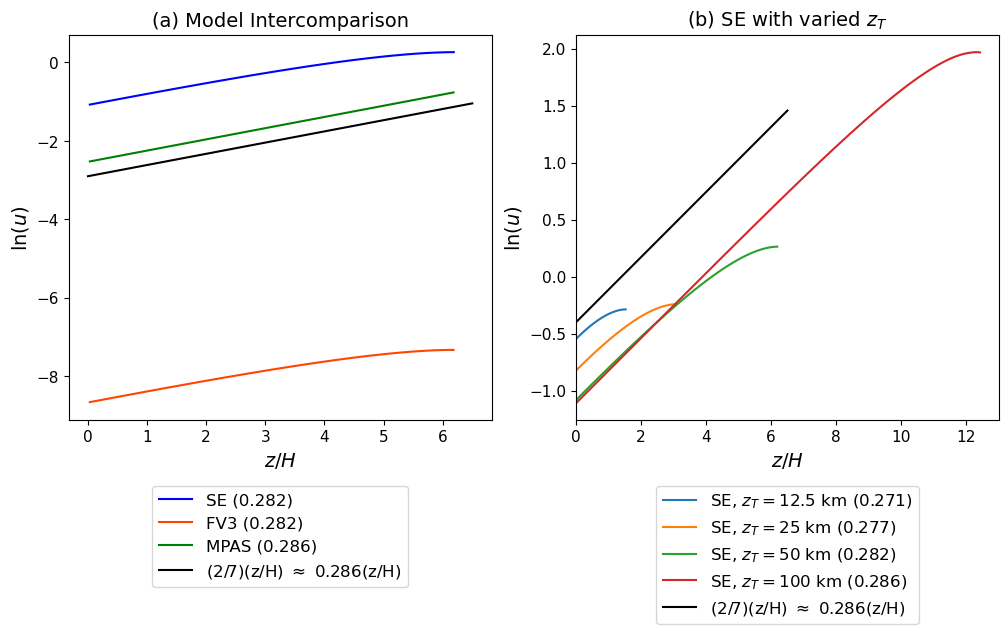

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
ax1,ax2 = axes

# Plot 1: all models and a 50 km model top.

ax1.plot(se_50_X, se_50_Y, c='b', label=f'SE ({se_50_fit:.3f})')
ax1.plot(fv3_X, fv3_Y, c='orangered', label=f'FV3 ({fv3_fit:.3f})')
ax1.plot(mpas_X, mpas_Y, c='g', label=f'MPAS ({mpas_fit:.3f})')
ax1.set_xlabel(r'$z/H$',size=14)
ax1.set_ylabel(r'ln($u$)',size=14)
ax1.set_title('(a) Model Intercomparison',size=14)

if case == 'p_pert':
    ax1.set_xlim([0, 6.5])
    ax1.set_ylim([-3,1])

# Plot a reference line
ref_X = np.linspace(0,6.5,100)
ax1.plot(ref_X, 2/7*ref_X-2.9, label=r'(2/7)(z/H) $\approx$ 0.286(z/H)', c='k')

ax1.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", fontsize=12)
ax1.tick_params(axis='both', labelsize=11)

# Plot 2: SE with different model top heights

ax2.plot(se_12_X, se_12_Y, label=r'SE, $z_T=12.5$ km' f' ({se_12_fit:.3f})')
ax2.plot(se_25_X, se_25_Y, label=r'SE, $z_T=25$ km' f' ({se_25_fit:.3f})')
ax2.plot(se_50_X, se_50_Y, label=r'SE, $z_T=50$ km' f' ({se_50_fit:.3f})')
ax2.plot(se_100_X, se_100_Y, label=r'SE, $z_T=100$ km' f' ({se_100_fit:.3f})')

ax2.plot(ref_X, 2/7*ref_X-0.4, label=r'(2/7)(z/H) $\approx$ 0.286(z/H)', c='k')

ax2.set_xlabel(r'$z/H$',size=14)
ax2.set_ylabel(r'ln($u$)',size=14)
ax2.set_title(r'(b) SE with varied $z_T$',size=14)

ax2.set_xlim([0, 13])

ax2.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", fontsize=12)
ax2.tick_params(axis='both', labelsize=11)


#Hmmm, instead of polyfit, fit a rough line:https://github.com/firedrakeproject/gusto
idx1 = 22
idx0 = 10
slope12 = (se_12_Y[idx1]-se_12_Y[idx0])/(se_12_X[idx1] - se_12_X[idx0])
print(slope12)

if case == 'p_pert':
    plt.savefig(f'figures/p_pert_vert_slopes.jpg', bbox_inches='tight')
#elif case == 'acid':
#    plt.savefig(f'figures/acid_vert_slopes.jpg', bbox_inches='tight')

In [16]:
# What about expected reduction in amplitude? 
# What are the surface velocities for each resolution?
se_12_U_surf = -se_12_U[-1]
se_25_U_surf = -se_25_U[-1]
se_50_U_surf = -se_50_U[-1]
se_100_U_surf = -se_100_U[-1]

B_12 = 0.4861
B_25 = 0.7360
B_50 = 0.9303
B_100 = 0.9951

print(se_12_U_surf)
print(se_25_U_surf)
print(se_50_U_surf)
print(se_100_U_surf)

print('\n')

print(se_12_U_surf**2*B_12)
print(se_25_U_surf**2*B_25)
print(se_50_U_surf**2*B_50)
print(se_100_U_surf**2*B_100)

# Or.. perhaps this would be true if we didn't have a sponge layer ... 

0.5839684
0.44239387
0.34173188
0.3324177


0.16576938
0.14404428
0.108641066
0.10996007
